# Results


In [1]:
%pip install scipy
%pip install mne

In [2]:
# Optional Colab Drive mount. Safe to skip/fail on non-Colab environments.
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path
import sys
import importlib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab_Notebooks/DERCo")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [4]:
import src.results_analysis as ra

importlib.reload(ra)

DERCO_ROOT = PROJECT_ROOT / 'outputs/runs'
print(DERCO_ROOT)
ra.set_derco_root(PROJECT_ROOT)
ra.ensure_analysis_dirs()

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DERCO_ROOT:", ra.DERCO_ROOT)
print("RUNS_ROOT:", ra.RUNS_ROOT)
print("TABLES_DIR:", ra.TABLES_DIR)
print("FIGURES_DIR:", ra.FIGURES_DIR)


/content/drive/MyDrive/Colab_Notebooks/DERCo/outputs/runs
PROJECT_ROOT: /content/drive/MyDrive/Colab_Notebooks/DERCo
DERCO_ROOT: /content/drive/MyDrive/Colab_Notebooks/DERCo
RUNS_ROOT: /content/drive/MyDrive/Colab_Notebooks/DERCo/outputs/runs
TABLES_DIR: /content/drive/MyDrive/Colab_Notebooks/DERCo/outputs/analysis/tables
FIGURES_DIR: /content/drive/MyDrive/Colab_Notebooks/DERCo/outputs/analysis/figures


## 1. Collect completed runs

In [5]:
all_runs = ra.collect_all_runs()

print(f"Total completed runs found: {len(all_runs)}")
display(all_runs["category"].value_counts().to_frame("count"))

cols = [
    "category", "run_name", "model", "model_display", "window", "sfreq",
    "shuffle_labels", "n_subjects_requested", "ablation_seed",
    "n_selected_subjects", "n_folds", "oof_auc", "oof_balanced_accuracy",
    "run_dir",
]
display(all_runs[[c for c in cols if c in all_runs.columns]].tail(50))


Total completed runs found: 148


,count
category,
subject_ablation,132
baseline,16


,category,run_name,model,model_display,window,sfreq,shuffle_labels,n_subjects_requested,ablation_seed,n_selected_subjects,n_folds,oof_auc,oof_balanced_accuracy,run_dir
98,subject_ablation,cnn_v2_0800_250hz_nsubj06_seed003,cnn_v2,CNN-v2,0800,250,False,6.0,3.0,6.0,5.0,0.603933,0.580046,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
99,subject_ablation,cnn_v2_0800_250hz_nsubj06_seed002,cnn_v2,CNN-v2,0800,250,False,6.0,2.0,6.0,5.0,0.599979,0.575464,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
100,subject_ablation,cnn_v2_0800_250hz_nsubj06_seed001,cnn_v2,CNN-v2,0800,250,False,6.0,1.0,6.0,5.0,0.587893,0.562796,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
101,subject_ablation,cnn_v2_0800_250hz_nsubj08_seed005,cnn_v2,CNN-v2,0800,250,False,8.0,5.0,8.0,5.0,0.611810,0.581027,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
102,subject_ablation,cnn_v2_0800_250hz_nsubj08_seed004,cnn_v2,CNN-v2,0800,250,False,8.0,4.0,8.0,5.0,0.603924,0.577508,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
103,subject_ablation,cnn_v2_0800_250hz_nsubj08_seed003,cnn_v2,CNN-v2,0800,250,False,8.0,3.0,8.0,5.0,0.598421,0.573019,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
104,subject_ablation,cnn_v2_0800_250hz_nsubj08_seed002,cnn_v2,CNN-v2,0800,250,False,8.0,2.0,8.0,5.0,0.576595,0.559682,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
105,subject_ablation,cnn_v2_0800_250hz_nsubj08_seed001,cnn_v2,CNN-v2,0800,250,False,8.0,1.0,8.0,5.0,0.591362,0.566753,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
106,subject_ablation,cnn_v2_0800_250hz_nsubj10_seed005,cnn_v2,CNN-v2,0800,250,False,10.0,5.0,10.0,5.0,0.598978,0.580719,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
107,subject_ablation,cnn_v2_0800_250hz_nsubj10_seed004,cnn_v2,CNN-v2,0800,250,False,10.0,4.0,10.0,5.0,0.601131,0.578290,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...


In [6]:
all_runs.to_csv(ra.TABLES_DIR / "all_runs_summary.csv", index=False)

## 2. Run integrity audit to check paths, sampling rate, timepoints, etc. 


In [7]:
integrity_audit = ra.make_run_integrity_audit(all_runs)
integrity_issues = ra.find_possible_integrity_issues(integrity_audit)

print(f"Integrity issues found: {len(integrity_issues)}")
display(integrity_issues)
display(integrity_audit)


Integrity issues found: 0


""


,category,run_name,model,model_display,model_name,window,sfreq,shuffle_labels,n_subjects_requested,ablation_seed,n_selected_subjects,n_selected_subjects_config,n_all_unique_subjects,n_unique_subjects,n_folds,X_train_val_shape,train_val_path,checkpoint_dir,run_dir
0,baseline,cnn_0200_250hz,cnn,CNN-v1,cnn,0200,250,False,NaN,NaN,NaN,NaN,NaN,18,NaN,"(28265, 32, 51)",/workspace/data/inputs,/workspace/data/checkpoints/cnn_0200_250hz,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
1,baseline,cnn_0800_250hz,cnn,CNN-v1,cnn,0800,250,False,NaN,NaN,NaN,NaN,NaN,18,NaN,"(28265, 32, 201)",/workspace/data/inputs,/workspace/data/checkpoints/cnn_0800_250hz,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
2,baseline,cnn_0800_250hz_shuffle,cnn,CNN-v1,cnn,0800,250,True,NaN,NaN,NaN,NaN,NaN,18,NaN,"(28265, 32, 201)",/workspace/data/inputs,/workspace/data/checkpoints/cnn_0800_250hz_shu...,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
3,baseline,cnn_300500_250hz,cnn,CNN-v1,cnn,300500,250,False,NaN,NaN,NaN,NaN,NaN,18,NaN,"(28265, 32, 51)",/workspace/data/inputs,/workspace/data/checkpoints/cnn_300500_250hz,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
4,baseline,cnn_500800_250hz,cnn,CNN-v1,cnn,500800,250,False,NaN,NaN,NaN,NaN,NaN,18,NaN,"(28265, 32, 76)",/workspace/data/inputs,/workspace/data/checkpoints/cnn_500800_250hz,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,subject_ablation,eegnet_0800_250hz_nsubj18_seed001,eegnet,EEGNet,eegnet,0800,250,False,18.0,1.0,18.0,18.0,18.0,18,5.0,"(28265, 32, 201)",/workspace/data/DERCo/inputs,/workspace/data/DERCo/checkpoints/subject_abla...,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
144,subject_ablation,eegnet_0800_250hz_nsubj18_seed002,eegnet,EEGNet,eegnet,0800,250,False,18.0,2.0,18.0,18.0,18.0,18,5.0,"(28265, 32, 201)",/workspace/data/DERCo/inputs,/workspace/data/DERCo/checkpoints/subject_abla...,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
145,subject_ablation,eegnet_0800_250hz_nsubj18_seed003,eegnet,EEGNet,eegnet,0800,250,False,18.0,3.0,18.0,18.0,18.0,18,5.0,"(28265, 32, 201)",/workspace/data/DERCo/inputs,/workspace/data/DERCo/checkpoints/subject_abla...,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
146,subject_ablation,eegnet_0800_250hz_nsubj18_seed004,eegnet,EEGNet,eegnet,0800,250,False,18.0,4.0,18.0,18.0,18.0,18,5.0,"(28265, 32, 201)",/workspace/data/DERCo/inputs,/workspace/data/DERCo/checkpoints/subject_abla...,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...


## 3. Baseline OOF performance table


In [8]:
baseline_summary = ra.make_baseline_summary(all_runs)

display(
    baseline_summary[
        [
            "run_name", "model_display", "window", "sfreq", "shuffle_labels",
            "oof_auc", "oof_balanced_accuracy", "oof_f1", "n_oof_samples",
        ]
    ] if not baseline_summary.empty else baseline_summary
)


,run_name,model_display,window,sfreq,shuffle_labels,oof_auc,oof_balanced_accuracy,oof_f1,n_oof_samples
0,cnn_0200_250hz,CNN-v1,0200,250,False,0.532839,0.526204,0.540916,28265
1,cnn_0800_250hz,CNN-v1,0800,250,False,0.553541,0.538708,0.540367,28265
2,cnn_0800_250hz_shuffle,CNN-v1,0800,250,True,0.531544,0.525808,0.535926,28265
3,cnn_300500_250hz,CNN-v1,300500,250,False,0.597125,0.570787,0.593514,28265
4,cnn_500800_250hz,CNN-v1,500800,250,False,0.564941,0.547861,0.529639,28265
5,cnn_v2_0200_250hz,CNN-v2,0200,250,False,0.542218,0.533331,0.541775,28265
6,cnn_v2_0800_250hz,CNN-v2,0800,250,False,0.617434,0.586990,0.590844,28265
7,cnn_v2_0800_250hz_shuffle,CNN-v2,0800,250,True,0.522589,0.518625,0.539905,28265
8,cnn_v2_300500_250hz,CNN-v2,300500,250,False,0.595217,0.570304,0.580854,28265
9,cnn_v2_500800_250hz,CNN-v2,500800,250,False,0.574018,0.556256,0.561996,28265


## 4. Shuffled-label + real-label checks

In [9]:
shuffled_sanity = ra.make_shuffled_sanity_table(baseline_summary)

display(shuffled_sanity)


,model,model_display,window,sfreq,real_run,shuffle_run,real_auc,shuffle_auc,auc_above_shuffle,real_bal_acc,shuffle_bal_acc,bal_acc_above_shuffle
0,cnn,CNN-v1,0800,250,cnn_0800_250hz,cnn_0800_250hz_shuffle,0.553541,0.531544,0.021997,0.538708,0.525808,0.012900
1,cnn_v2,CNN-v2,0800,250,cnn_v2_0800_250hz,cnn_v2_0800_250hz_shuffle,0.617434,0.522589,0.094845,0.586990,0.518625,0.068365
2,eegnet,EEGNet,0800,250,eegnet_0800_250hz,eegnet_0800_250hz_shuffle,0.616576,0.519767,0.096809,0.585812,0.515353,0.070459


## 5. Architecture comparison: 0–800 ms, 250 Hz



In [10]:
importlib.reload(ra)

<module 'src.results_analysis' from '/content/drive/MyDrive/Colab_Notebooks/DERCo/src/results_analysis.py'>

,found,run_name,model,model_display,window,sfreq,shuffle_labels,oof_auc,oof_balanced_accuracy,oof_f1,threshold_used,n_oof_samples,run_dir
0,True,cnn_0800_250hz_shuffle,cnn,CNN-v1,0800,250,True,0.531544,0.525808,0.535926,0.497,28265,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
1,True,cnn_0800_250hz,cnn,CNN-v1,0800,250,False,0.553541,0.538708,0.540367,0.493,28265,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
2,True,cnn_v2_0800_250hz_shuffle,cnn_v2,CNN-v2,0800,250,True,0.522589,0.518625,0.539905,0.487,28265,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
3,True,cnn_v2_0800_250hz,cnn_v2,CNN-v2,0800,250,False,0.617434,0.586990,0.590844,0.479,28265,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
4,True,eegnet_0800_250hz_shuffle,eegnet,EEGNet,0800,250,True,0.519767,0.515353,0.566574,0.488,28265,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
5,True,eegnet_0800_250hz,eegnet,EEGNet,0800,250,False,0.616576,0.585812,0.595248,0.488,28265,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...


,comparison,run_a,run_b,available,auc_difference,balanced_accuracy_difference,f1_difference
0,CNN-v2 minus CNN-v1,cnn_v2_0800_250hz,cnn_0800_250hz,True,0.063892,0.048282,0.050477
1,EEGNet minus CNN-v1,eegnet_0800_250hz,cnn_0800_250hz,True,0.063035,0.047104,0.054881
2,EEGNet minus CNN-v2,eegnet_0800_250hz,cnn_v2_0800_250hz,True,-0.000857,-0.001178,0.004404
3,CNN-v1 minus CNN-v1 shuffled,cnn_0800_250hz,cnn_0800_250hz_shuffle,True,0.021997,0.012900,0.004442
4,CNN-v2 minus CNN-v2 shuffled,cnn_v2_0800_250hz,cnn_v2_0800_250hz_shuffle,True,0.094845,0.068365,0.050938
5,EEGNet minus EEGNet shuffled,eegnet_0800_250hz,eegnet_0800_250hz_shuffle,True,0.096809,0.070459,0.028674


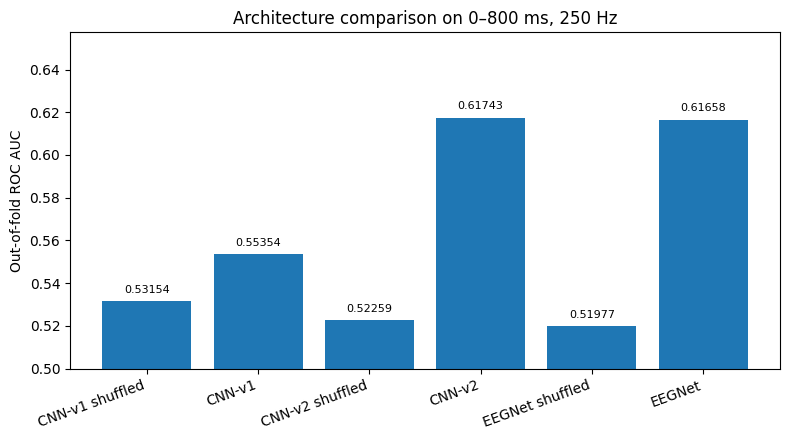

In [11]:
architecture_comparison = ra.make_architecture_comparison(baseline_summary)
architecture_differences = ra.make_architecture_difference_table(architecture_comparison)

display(architecture_comparison)
display(architecture_differences)

if architecture_comparison["found"].any():
    fig, ax = ra.plot_architecture_comparison(
        architecture_comparison,
        save_path=ra.FIGURES_DIR / "architecture_comparison_0800_auc.png",
    )
else:
    print("No architecture baseline runs available to plot.")


## 6. Temporal-window analysis

,run_name,model,model_display,window,window_label,sfreq,oof_auc,oof_balanced_accuracy,oof_f1,threshold_used,n_oof_samples
0,cnn_0200_250hz,cnn,CNN-v1,0200,0–200 ms,250,0.532839,0.526204,0.540916,0.493,28265
1,cnn_v2_0200_250hz,cnn_v2,CNN-v2,0200,0–200 ms,250,0.542218,0.533331,0.541775,0.490,28265
2,cnn_300500_250hz,cnn,CNN-v1,300500,300–500 ms,250,0.597125,0.570787,0.593514,0.489,28265
3,cnn_v2_300500_250hz,cnn_v2,CNN-v2,300500,300–500 ms,250,0.595217,0.570304,0.580854,0.490,28265
4,cnn_500800_250hz,cnn,CNN-v1,500800,500–800 ms,250,0.564941,0.547861,0.529639,0.504,28265
5,cnn_v2_500800_250hz,cnn_v2,CNN-v2,500800,500–800 ms,250,0.574018,0.556256,0.561996,0.484,28265
6,cnn_0800_250hz,cnn,CNN-v1,0800,0–800 ms,250,0.553541,0.538708,0.540367,0.493,28265
7,cnn_v2_0800_250hz,cnn_v2,CNN-v2,0800,0–800 ms,250,0.617434,0.586990,0.590844,0.479,28265


,window,window_label,cnn_auc,cnn_v2_auc,auc_delta_v2_minus_cnn,cnn_bal_acc,cnn_v2_bal_acc,bal_acc_delta_v2_minus_cnn,cnn_f1,cnn_v2_f1,f1_delta_v2_minus_cnn
0,0200,0–200 ms,0.532839,0.542218,0.009379,0.526204,0.533331,0.007128,0.540916,0.541775,0.000859
1,300500,300–500 ms,0.597125,0.595217,-0.001908,0.570787,0.570304,-0.000483,0.593514,0.580854,-0.012660
2,500800,500–800 ms,0.564941,0.574018,0.009077,0.547861,0.556256,0.008395,0.529639,0.561996,0.032357
3,0800,0–800 ms,0.553541,0.617434,0.063892,0.538708,0.586990,0.048282,0.540367,0.590844,0.050477


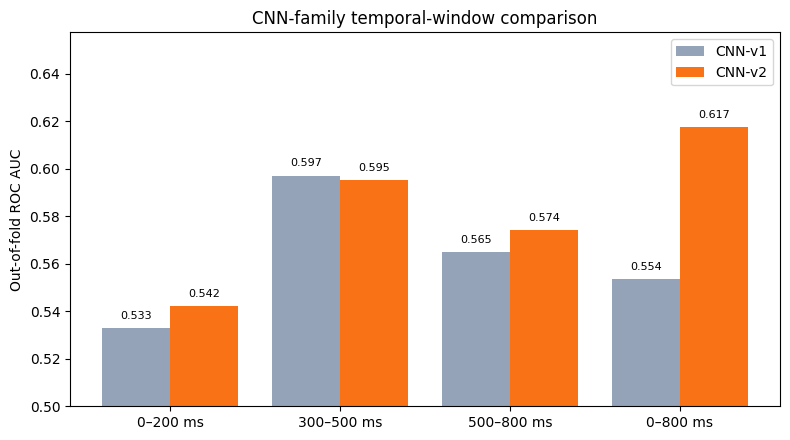

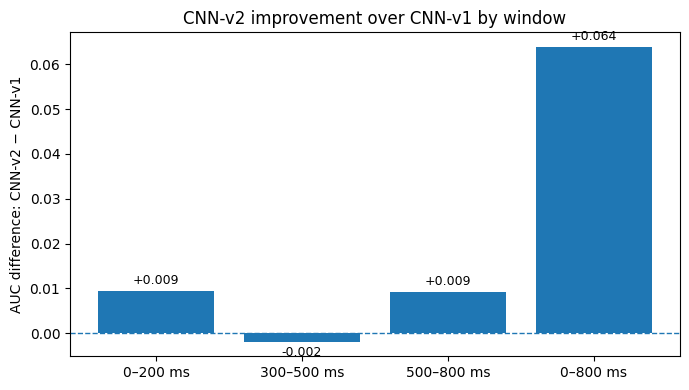

In [14]:
temporal_summary = ra.make_temporal_window_summary(baseline_summary)
temporal_delta = ra.make_cnn_v2_window_delta_table(temporal_summary)

display(temporal_summary)
display(temporal_delta)

if not temporal_summary.empty:
    fig, ax = ra.plot_temporal_window_auc(
        temporal_summary,
        save_path=ra.FIGURES_DIR / "temporal_window_auc_cnn_family.png",
    )

if not temporal_delta.empty:
    fig, ax = ra.plot_cnn_v2_window_delta(
        temporal_delta,
        save_path=ra.FIGURES_DIR / "cnn_v2_window_delta_auc.png",
    )
else:
    print("CNN-v2 temporal-window deltas unavailable because CNN-v2 baseline windows are missing.")


## 7. Subject-count ablation: raw learning curve



In [28]:
importlib.reload(ra)

# Filter to 0–800 ms only for the main learning curve comparison
all_runs_0800 = all_runs[all_runs["window"] == "0800"]

ablation_runs   = ra.make_subject_ablation_runs(all_runs_0800)
ablation_summary = ra.make_subject_ablation_summary(all_runs_0800)

,run_name,model,model_display,subject_count,n_subjects_requested,ablation_seed,selected_subjects,selected_subjects_key,n_folds,oof_auc,oof_accuracy,oof_balanced_accuracy,oof_f1,global_threshold,threshold_used,n_oof_samples,run_dir
0,cnn_0800_250hz_nsubj02_seed001,cnn,CNN-v1,2.0,2.0,1.0,"[OLW10, QFT39]",OLW10|QFT39,2.0,0.548914,0.544561,0.543773,0.475584,0.492,0.492,3254,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
1,cnn_0800_250hz_nsubj02_seed002,cnn,CNN-v1,2.0,2.0,2.0,"[LYY64, TRA37]",LYY64|TRA37,2.0,0.556951,0.545455,0.546513,0.571168,0.433,0.433,3102,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
2,cnn_0800_250hz_nsubj02_seed003,cnn,CNN-v1,2.0,2.0,3.0,"[HMK96, SIT48]",HMK96|SIT48,2.0,0.526013,0.532208,0.531376,0.578261,0.525,0.525,2903,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
3,cnn_0800_250hz_nsubj02_seed004,cnn,CNN-v1,2.0,2.0,4.0,"[SAB93, WHR08]",SAB93|WHR08,2.0,0.522959,0.527139,0.525869,0.470103,0.517,0.517,3261,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
4,cnn_0800_250hz_nsubj02_seed005,cnn,CNN-v1,2.0,2.0,5.0,"[RRO98, TRA37]",RRO98|TRA37,2.0,0.524819,0.526466,0.528316,0.565192,0.476,0.476,3155,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
5,cnn_0800_250hz_nsubj04_seed001,cnn,CNN-v1,4.0,4.0,1.0,"[NXB64, OLW10, SAB93, WJX11]",NXB64|OLW10|SAB93|WJX11,4.0,0.544083,0.537931,0.537616,0.523500,0.497,0.497,6670,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
6,cnn_0800_250hz_nsubj04_seed002,cnn,CNN-v1,4.0,4.0,2.0,"[HMK96, LYY64, MNY88, SAB93]",HMK96|LYY64|MNY88|SAB93,4.0,0.553402,0.542060,0.542214,0.551805,0.489,0.489,6669,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
7,cnn_0800_250hz_nsubj04_seed003,cnn,CNN-v1,4.0,4.0,3.0,"[HMK96, LRK01, LYY64, SAB93]",HMK96|LRK01|LYY64|SAB93,4.0,0.552201,0.544480,0.544389,0.536388,0.494,0.494,6531,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
8,cnn_0800_250hz_nsubj04_seed004,cnn,CNN-v1,4.0,4.0,4.0,"[QFT39, QPI83, TRA37, UJM92]",QFT39|QPI83|TRA37|UJM92,4.0,0.572724,0.560205,0.557648,0.490433,0.499,0.499,6237,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...
9,cnn_0800_250hz_nsubj04_seed005,cnn,CNN-v1,4.0,4.0,5.0,"[DGR11, QPI83, SAB93, TRA37]",DGR11|QPI83|SAB93|TRA37,4.0,0.540407,0.539322,0.535772,0.455404,0.502,0.502,6256,/content/drive/MyDrive/Colab_Notebooks/DERCo/o...


,model,model_display,subject_count,mean_auc,std_auc,sem_auc,mean_bal_acc,std_bal_acc,sem_bal_acc,n_runs,n_unique_subject_sets,mean_n_oof_samples
0,cnn,CNN-v1,2.0,0.535931,0.015816,0.007073,0.535169,0.009362,0.004187,5,5,3135.0
1,cnn,CNN-v1,4.0,0.552563,0.012520,0.005599,0.543528,0.008616,0.003853,5,5,6472.6
2,cnn,CNN-v1,6.0,0.552353,0.008735,0.003907,0.541414,0.007646,0.003419,5,5,9463.0
3,cnn,CNN-v1,8.0,0.553183,0.014427,0.006452,0.540970,0.010392,0.004647,5,5,12489.0
4,cnn,CNN-v1,10.0,0.549086,0.005815,0.002600,0.537788,0.003818,0.001707,5,5,15898.8
5,cnn,CNN-v1,14.0,0.554887,0.006121,0.002738,0.539626,0.005357,0.002396,5,5,21825.6
6,cnn,CNN-v1,18.0,0.553541,NaN,NaN,0.538708,NaN,NaN,5,1,28265.0
7,cnn_v2,CNN-v2,2.0,0.555607,0.031197,0.013952,0.547061,0.023405,0.010467,5,5,3135.0
8,cnn_v2,CNN-v2,4.0,0.580219,0.012445,0.005566,0.562108,0.011803,0.005278,5,5,6472.6
9,cnn_v2,CNN-v2,6.0,0.592118,0.012680,0.005671,0.570158,0.009987,0.004466,5,5,9463.0


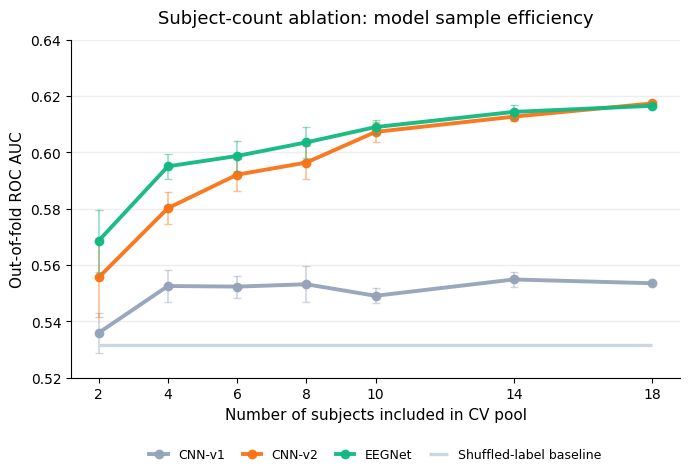

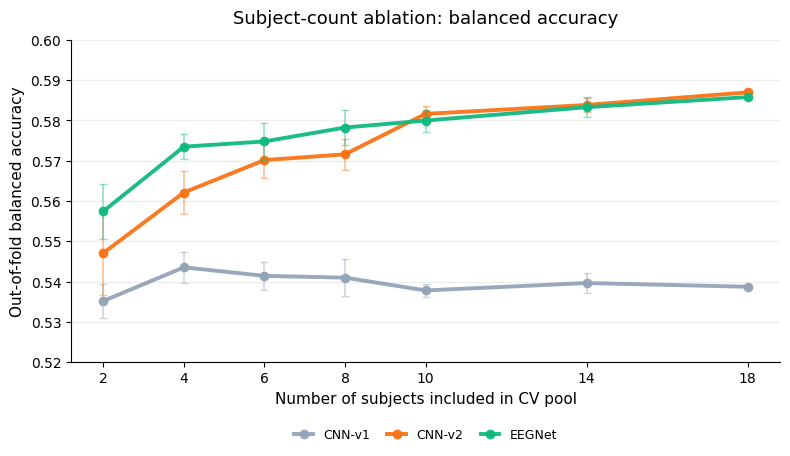

In [29]:
# ablation_runs = ra.make_subject_ablation_runs(all_runs)
# ablation_summary = ra.make_subject_ablation_summary(all_runs)

ablation_summary = ablation_summary[
    ablation_summary["subject_count"] != 12
]

display(ablation_runs.head(30))
display(ablation_summary)

if not ablation_summary.empty:
    fig, ax = ra.plot_subject_ablation_auc(
        ablation_summary,
        save_path=ra.FIGURES_DIR / "subject_ablation_auc_curve.png",
    )

    fig, ax = ra.plot_subject_ablation_bal_acc(
        ablation_summary,
        save_path=ra.FIGURES_DIR / "subject_ablation_balanced_accuracy_curve.png",
    )
else:
    print("No subject-ablation runs found.")


## 8. AUC above each model's own shuffled baseline

,model_display,subject_count,mean_auc,model_shuffle_auc,mean_auc_above_shuffle,sem_auc,n_runs,n_unique_subject_sets
0,CNN-v1,2.0,0.535931,0.531544,0.004387,0.007073,5,5
1,CNN-v1,4.0,0.552563,0.531544,0.021019,0.005599,5,5
2,CNN-v1,6.0,0.552353,0.531544,0.020809,0.003907,5,5
3,CNN-v1,8.0,0.553183,0.531544,0.021639,0.006452,5,5
4,CNN-v1,10.0,0.549086,0.531544,0.017542,0.002600,5,5
5,CNN-v1,14.0,0.554887,0.531544,0.023343,0.002738,5,5
6,CNN-v1,18.0,0.553541,0.531544,0.021997,NaN,5,1
7,CNN-v2,2.0,0.555607,0.522589,0.033018,0.013952,5,5
8,CNN-v2,4.0,0.580219,0.522589,0.057630,0.005566,5,5
9,CNN-v2,6.0,0.592118,0.522589,0.069529,0.005671,5,5


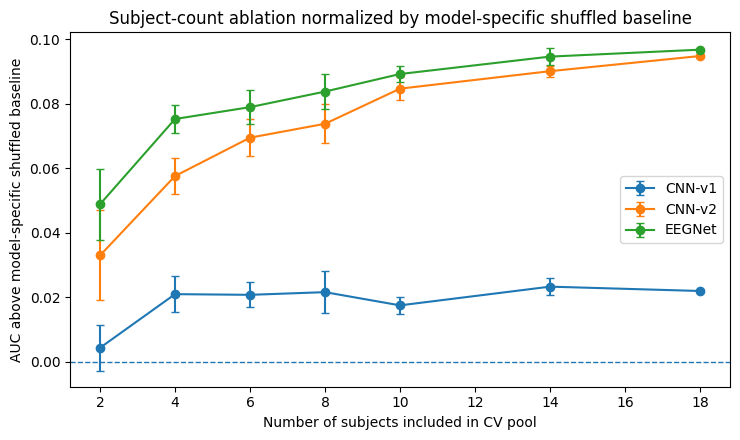

In [18]:
ablation_adjusted = ra.add_auc_above_model_shuffle(
    ablation_summary,
    baseline_summary,
    window="0800",
    sfreq=250,
)

display(
    ablation_adjusted[
        [
            "model_display", "subject_count", "mean_auc", "model_shuffle_auc",
            "mean_auc_above_shuffle", "sem_auc", "n_runs", "n_unique_subject_sets",
        ]
    ] if not ablation_adjusted.empty else ablation_adjusted
)

try:
    fig, ax = ra.plot_subject_ablation_auc_above_shuffle(
        ablation_adjusted,
        save_path=ra.FIGURES_DIR / "subject_ablation_auc_above_model_shuffle.png",
    )
except ValueError as e:
    print(e)


## 9. Paired t-tests + Cohen's d

Pairwise model comparisons across subject-count levels using paired t-tests (paired by `ablation_seed`, which selects the same subjects for all models). Bonferroni correction applied across all 18 tests.

n=18 excluded (subsampling doesn't work here because the full sample is n=18)

,comparison,model_a,model_b,n_subjects,mean_a,mean_b,mean_diff,std_diff,t_stat,p_value,cohens_d,p_bonferroni,sig_raw,sig_bonferroni
0,eegnet vs cnn,eegnet,cnn,2,0.5687,0.5359,0.0327,0.0295,2.477,0.0685,1.108,1.0000,ns,ns
1,eegnet vs cnn,eegnet,cnn,4,0.5951,0.5526,0.0425,0.0128,7.423,0.0018,3.320,0.0324,**,*
2,eegnet vs cnn,eegnet,cnn,6,0.5988,0.5524,0.0464,0.0129,8.047,0.0013,3.599,0.0234,**,*
3,eegnet vs cnn,eegnet,cnn,8,0.6036,0.5532,0.0504,0.0097,11.668,0.0003,5.218,0.0054,***,**
4,eegnet vs cnn,eegnet,cnn,10,0.6090,0.5491,0.0599,0.0048,28.151,0.0000,12.589,0.0000,***,***
5,eegnet vs cnn,eegnet,cnn,14,0.6144,0.5549,0.0595,0.0045,29.299,0.0000,13.103,0.0000,***,***
6,cnn_v2 vs cnn,cnn_v2,cnn,2,0.5556,0.5359,0.0197,0.0341,1.292,0.2660,0.578,1.0000,ns,ns
7,cnn_v2 vs cnn,cnn_v2,cnn,4,0.5802,0.5526,0.0277,0.0130,4.748,0.0090,2.124,0.1620,**,ns
8,cnn_v2 vs cnn,cnn_v2,cnn,6,0.5921,0.5524,0.0398,0.0112,7.923,0.0014,3.543,0.0252,**,*
9,cnn_v2 vs cnn,cnn_v2,cnn,8,0.5964,0.5532,0.0432,0.0142,6.804,0.0024,3.043,0.0432,**,*


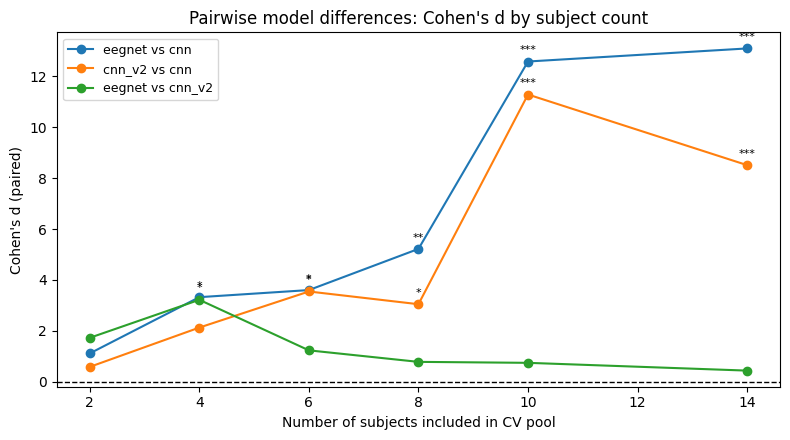

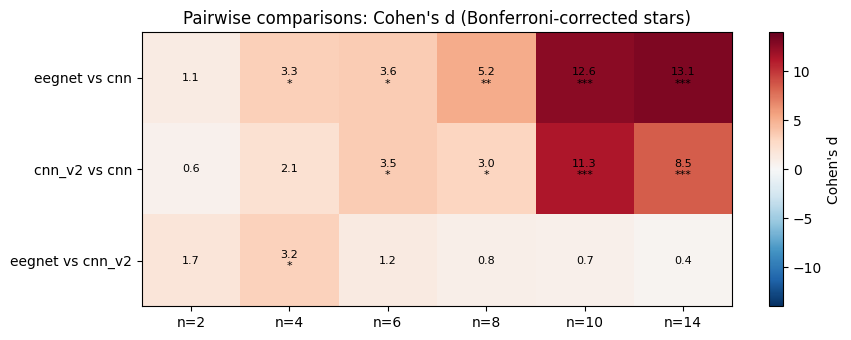

In [34]:
importlib.reload(ra)

ttest_results = ra.make_paired_ttest_results(ablation_runs)

display(ttest_results)

# Save table
ttest_results.to_csv(ra.TABLES_DIR / "paired_ttest_cohens_d.csv", index=False)

# Cohen's d line plot
fig, ax = ra.plot_cohens_d_by_n(
    ttest_results,
    save_path=ra.FIGURES_DIR / "cohens_d_by_n_subjects.png",
)

# Significance heatmap
fig, ax = ra.plot_ttest_significance_grid(
    ttest_results,
    save_path=ra.FIGURES_DIR / "ttest_significance_grid.png",
)

In [20]:
ra.save_priority_tables(
    all_runs=all_runs,
    integrity_audit=integrity_audit,
    integrity_issues=integrity_issues,
    baseline_summary=baseline_summary,
    shuffled_sanity=shuffled_sanity,
    architecture_comparison=architecture_comparison,
    architecture_differences=architecture_differences,
    temporal_summary=temporal_summary,
    temporal_delta=temporal_delta,
    ablation_runs=ablation_runs,
    ablation_summary=ablation_summary,
    paired_ttests=ttest_results,
)

print(f"Saved tables to: {ra.TABLES_DIR}")
print(f"Saved figures to: {ra.FIGURES_DIR}")


Saved tables to: /content/drive/MyDrive/Colab_Notebooks/DERCo/outputs/analysis/tables
Saved figures to: /content/drive/MyDrive/Colab_Notebooks/DERCo/outputs/analysis/figures


## 10. OOF predicted probability distributions

Loaded distributions for: ['cnn_0800_250hz', 'cnn_v2_0800_250hz', 'eegnet_0800_250hz']


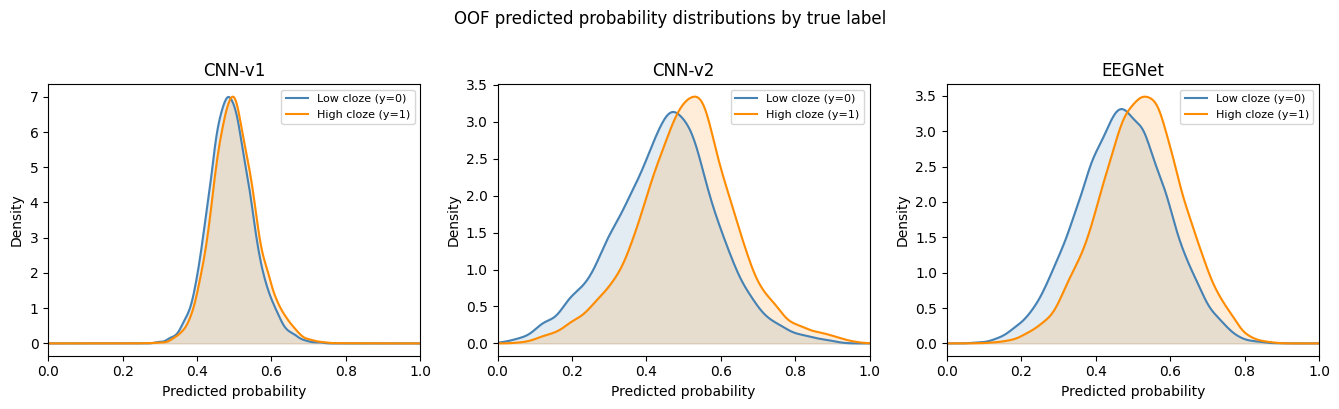

In [21]:
importlib.reload(ra)

distributions = ra.make_oof_prob_distributions(baseline_summary)

print(f"Loaded distributions for: {list(distributions.keys())}")

fig, axes = ra.plot_oof_probability_distributions(
    distributions,
    save_path=ra.FIGURES_DIR / "oof_probability_distributions.png",
)

## 12. Gradient saliency maps

Computes `|∂output/∂input|` for every trial, averaged across folds and optionally split by label. 
Strong saliency at centroparietal channels (Cz, CP1, CP2, Pz) in the 300–500 ms window 
would confirm the model is capturing N400-related features.

In [ ]:
import numpy as np

X_raw = np.load(PROJECT_ROOT / 'processed_data_250hz/train_val/X_0800.npy')   # (28265, 32, 201)
y     = np.load(PROJECT_ROOT / 'processed_data_250hz/train_val/y.npy')        # (28265,)

import mne
sample_fif = mne.read_epochs(PROJECT_ROOT/'inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed/ACB71/article_0/preprocessed_epoch.fif', preload=False)
mne_info = sample_fif.info

CKPT_ROOT = PROJECT_ROOT / 'checkpoints'

run_dirs = {
    'cnn_v2':  CKPT_ROOT / 'baseline' / 'cnn_v2_0800_250hz',
    'eegnet':  CKPT_ROOT / 'baseline' / 'eegnet_0800_250hz',
}

print('X_raw:', X_raw.shape, '  y:', y.shape)

Reading /content/drive/MyDrive/Colab_Notebooks/DERCo/inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed/ACB71/article_0/preprocessed_epoch.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 32) active
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 10 columns
451 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
X_raw: (28265, 32, 201)   y: (28265,)


/tmp/ipykernel_18252/2117475584.py:8: RuntimeWarning: This filename (/content/drive/MyDrive/Colab_Notebooks/DERCo/inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed/ACB71/article_0/preprocessed_epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  sample_fif = mne.read_epochs(PROJECT_ROOT/'inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed/ACB71/article_0/preprocessed_epoch.fif', preload=False)


In [27]:
import importlib
import src.results_analysis as ra
importlib.reload(ra)

<module 'src.results_analysis' from '/content/drive/MyDrive/Colab_Notebooks/DERCo/src/results_analysis.py'>

In [ ]:
saliency = {}

for model_name, run_dir in run_dirs.items():
    print(f'Computing saliency for {model_name}...')
    saliency[model_name] = ra.compute_gradient_saliency(
        run_dir=run_dir,
        X_raw=X_raw,
        y=y,
        model_name=model_name,
        sfreq=250,
        device='cuda', 
    )
    n = saliency[model_name]
    print(f'  Folds: {n["n_folds"]}  |  High: {n["n_trials_high"]}  |  Low: {n["n_trials_low"]}')

Computing saliency for cnn_v2...
  Folds: 5  |  High: 13934  |  Low: 14331
Computing saliency for eegnet...
  Folds: 5  |  High: 13934  |  Low: 14331


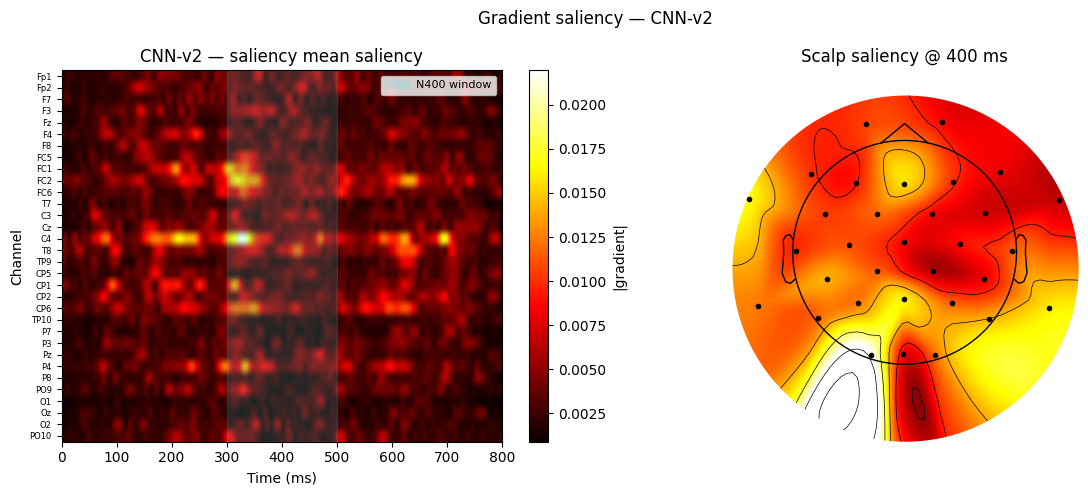

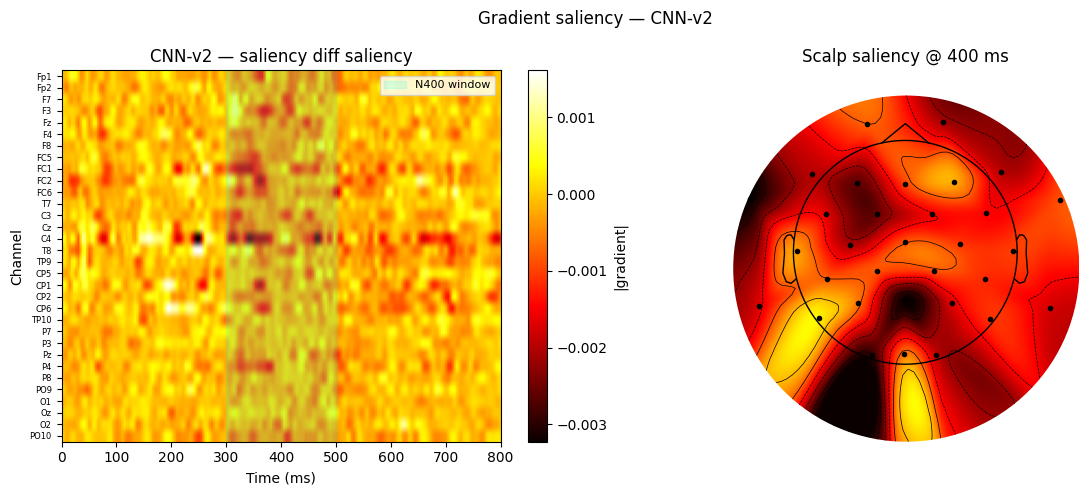

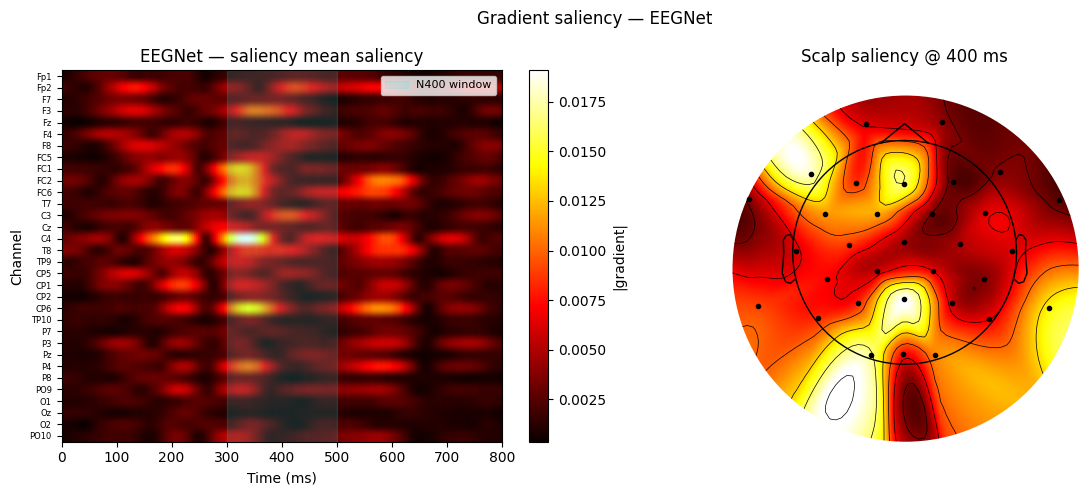

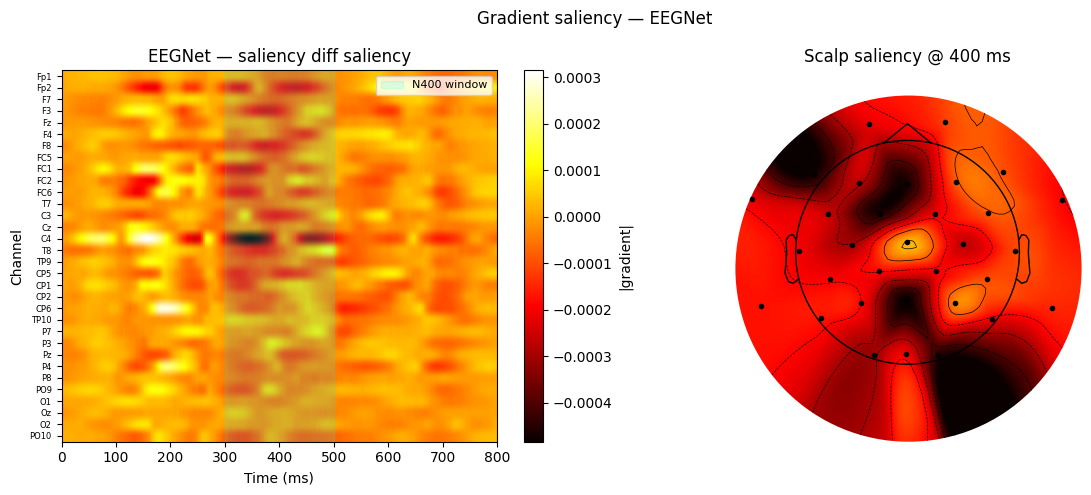

In [ ]:
for model_name, sal in saliency.items():
    display_label = ra.MODEL_LABELS.get(model_name, model_name)

    for key in ('saliency_mean', 'saliency_diff'):
        fig, axes = ra.plot_saliency_single(
            saliency=sal,
            model_display=display_label,
            window_ms=(0, 800),
            peak_ms=400,
            mne_info=mne_info,
            key=key,
            save_path=ra.FIGURES_DIR / f'saliency_{model_name}_{key}.png',
        )
        plt.show()

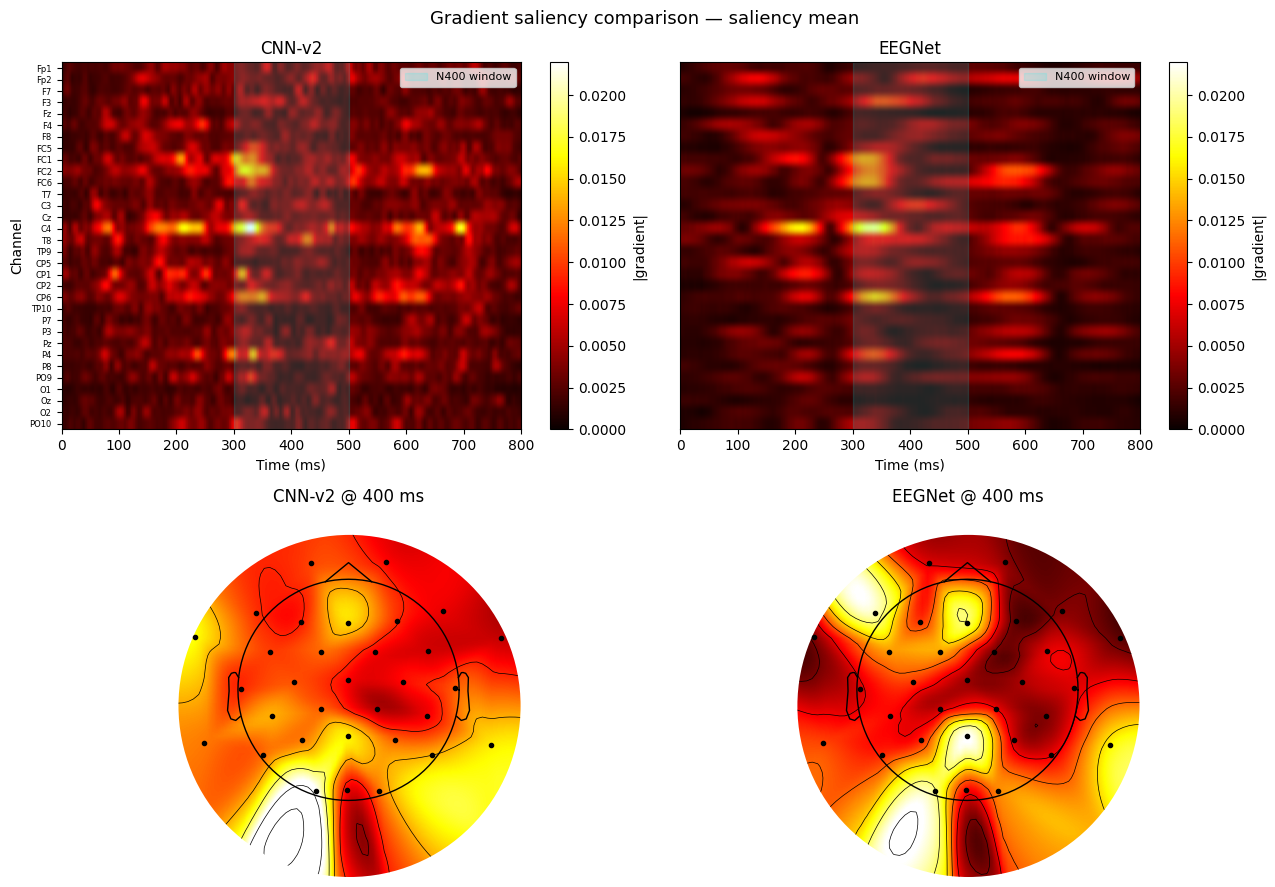

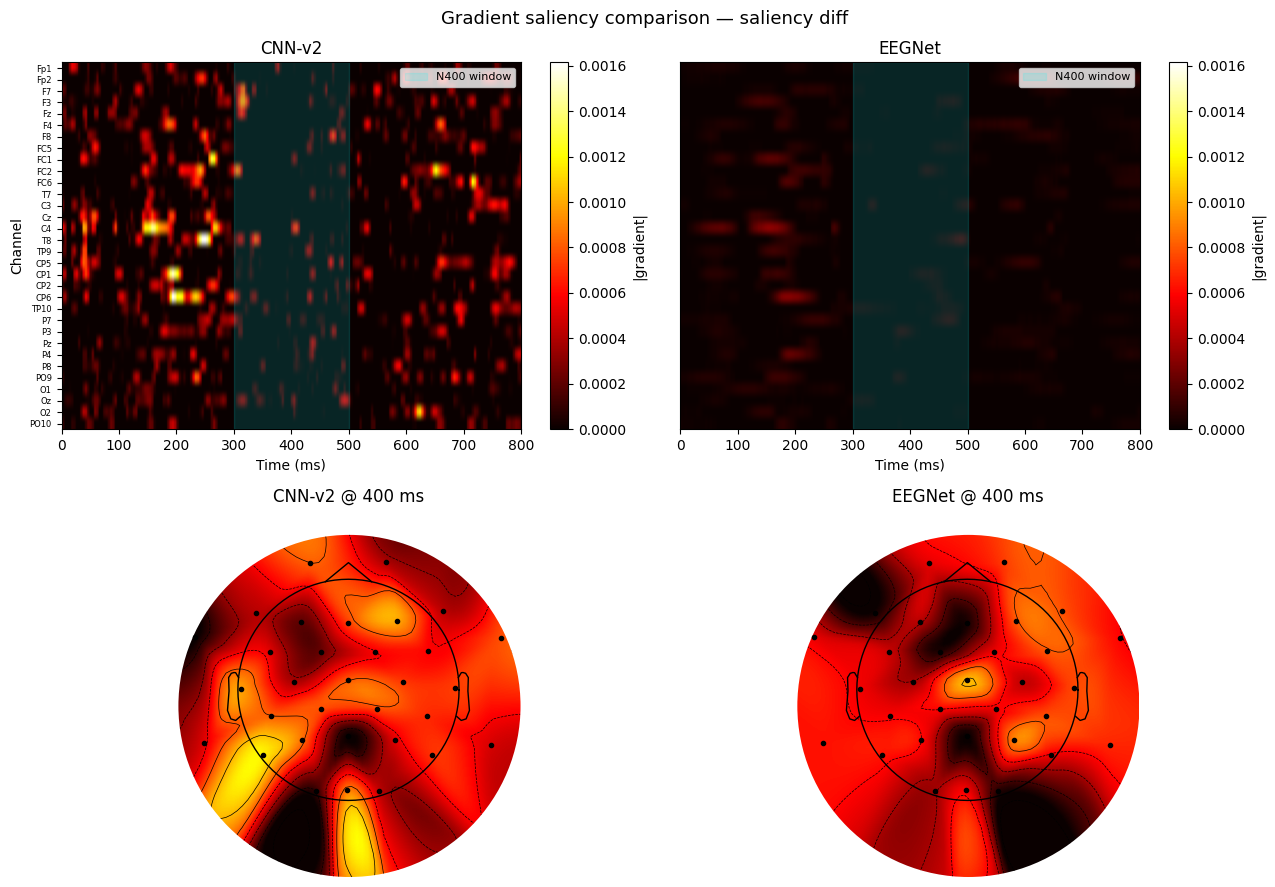

In [ ]:
if 'cnn_v2' in saliency and 'eegnet' in saliency:
    for key in ('saliency_mean', 'saliency_diff'):
        fig, axes = ra.plot_saliency_comparison(
            saliency_a=saliency['cnn_v2'],
            saliency_b=saliency['eegnet'],
            label_a='CNN-v2',
            label_b='EEGNet',
            window_ms=(0, 800),
            peak_ms=400,
            mne_info=mne_info,
            key=key,
            save_path=ra.FIGURES_DIR / f'saliency_comparison_{key}.png',
        )
        plt.show()

## 12. Training curves from epoch logs

Training-curve runs: ['cnn_0800_250hz', 'cnn_v2_0800_250hz', 'eegnet_0800_250hz']


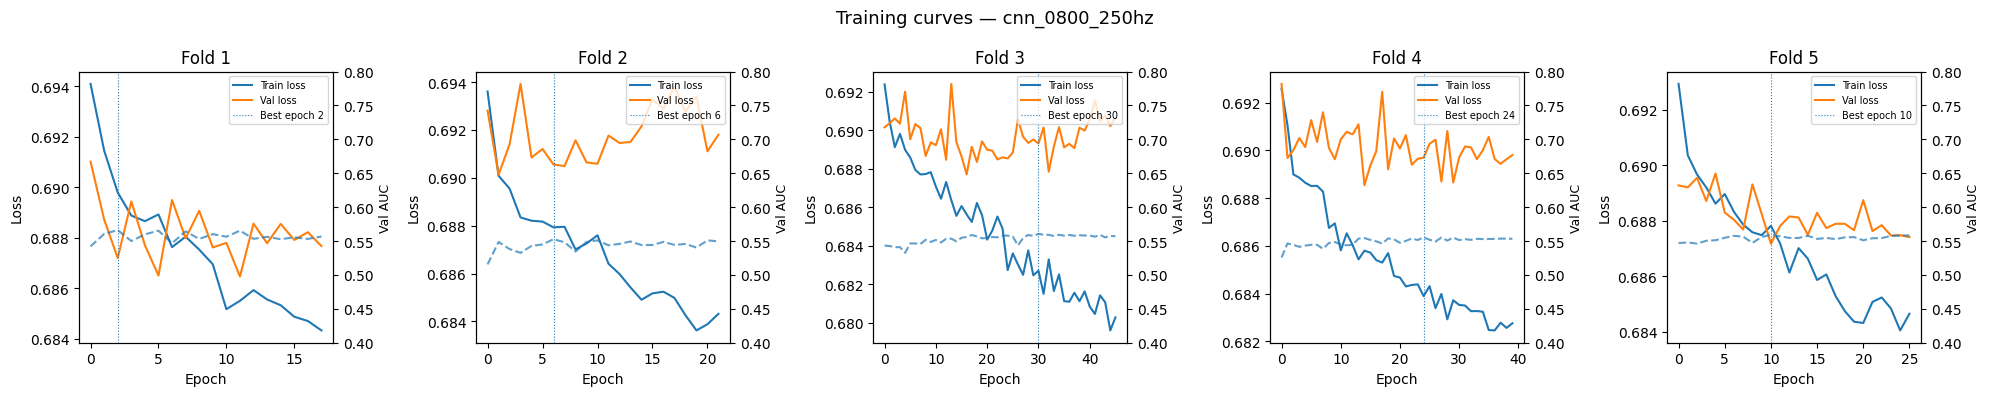

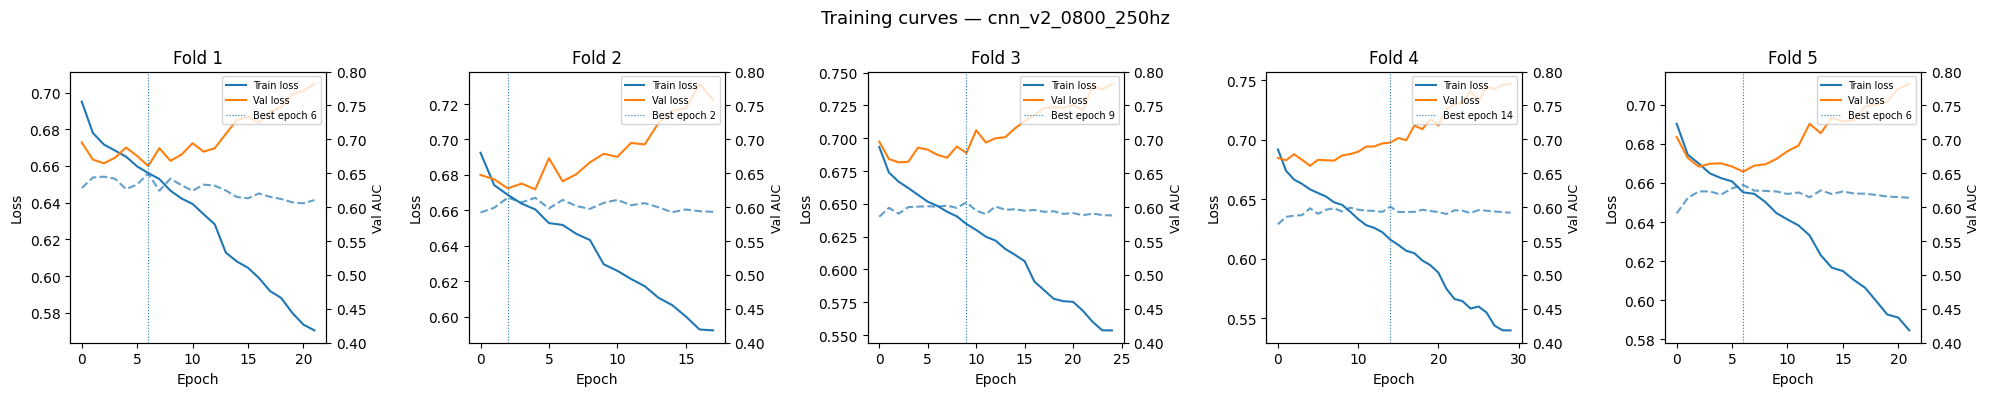

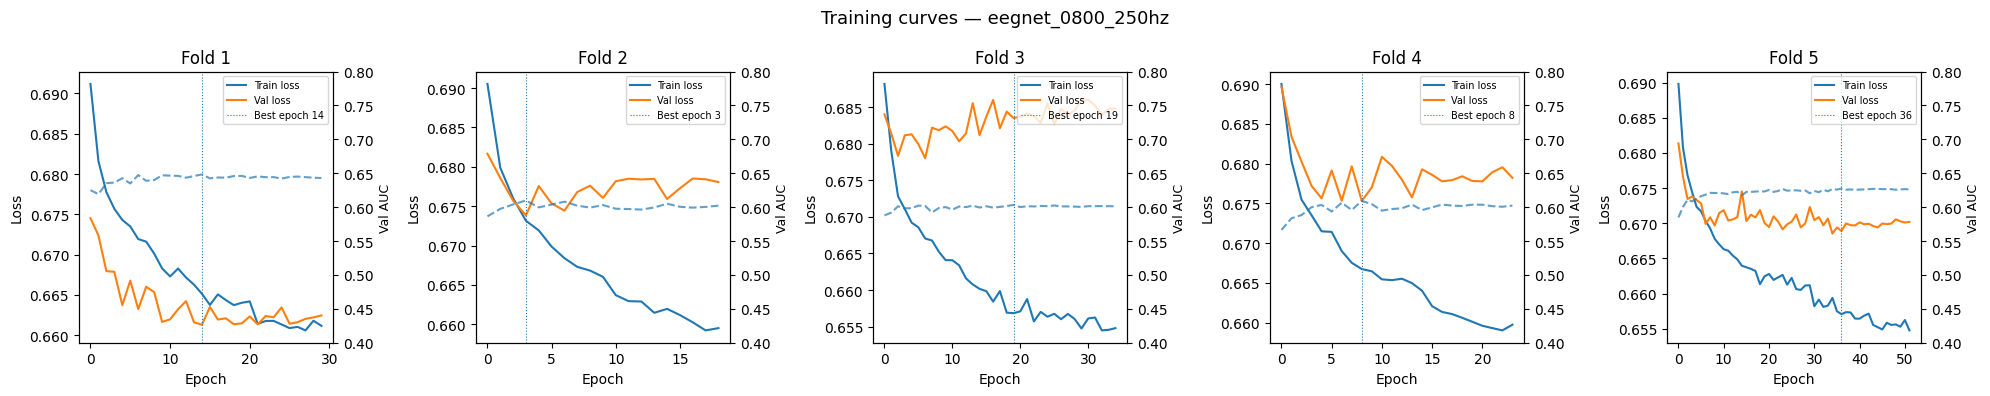

In [ ]:
importlib.reload(ra)

training_curve_runs = [
    "cnn_0800_250hz",
    "cnn_v2_0800_250hz",
    "eegnet_0800_250hz",
]

available_training_runs = [
    r for r in training_curve_runs
    if not baseline_summary[baseline_summary["run_name"] == r].empty
]

print("Training-curve runs:", available_training_runs)

figs = ra.plot_training_curves_for_runs(
    available_training_runs,
    runs_root=ra.RUNS_ROOT,
    save=True,
)


## 13. Baseline paired fold t-tests (fold-level AUCs)

In [32]:
importlib.reload(ra)

baseline_comparisons = [
    ("cnn_v2_0800_250hz", "cnn_0800_250hz"),
    ("eegnet_0800_250hz", "cnn_0800_250hz"),
    ("eegnet_0800_250hz", "cnn_v2_0800_250hz"),
]


baseline_ttests = ra.make_paired_ttest_table(
    baseline_comparisons,
    runs_root=ra.RUNS_ROOT,
)

display(baseline_ttests)
baseline_ttests.to_csv(ra.TABLES_DIR / "baseline_paired_fold_ttests.csv", index=False)


,run_a,run_b,n_folds,mean_auc_a,mean_auc_b,mean_diff_a_minus_b,t,p,df,a_wins_every_fold,auc_a_per_fold,auc_b_per_fold
0,cnn_v2_0800_250hz,cnn_0800_250hz,5,0.620862,0.558821,0.062041,8.319010,0.001141,4,True,"[0.649644, 0.614053, 0.60715, 0.600686, 0.632777]","[0.566167, 0.552716, 0.560622, 0.555363, 0.559..."
1,eegnet_0800_250hz,cnn_0800_250hz,5,0.619657,0.558821,0.060836,9.072897,0.000818,4,True,"[0.648277, 0.609906, 0.603292, 0.609286, 0.627...","[0.566167, 0.552716, 0.560622, 0.555363, 0.559..."
2,eegnet_0800_250hz,cnn_v2_0800_250hz,5,0.619657,0.620862,-0.001205,-0.475829,0.659018,4,False,"[0.648277, 0.609906, 0.603292, 0.609286, 0.627...","[0.649644, 0.614053, 0.60715, 0.600686, 0.632777]"


## 14. Paired bootstrap AUC differences

In [33]:
importlib.reload(ra)

bootstrap_comparisons = [
    ("cnn_v2_0800_250hz", "cnn_0800_250hz"),
    ("eegnet_0800_250hz", "cnn_0800_250hz"),
    ("eegnet_0800_250hz", "cnn_v2_0800_250hz"),
]

bootstrap_results = ra.make_bootstrap_auc_table(
    bootstrap_comparisons,
    runs_root=ra.RUNS_ROOT,
    n_boot=500,
    seed=42,
)

display(bootstrap_results)
bootstrap_results.to_csv(ra.TABLES_DIR / "baseline_paired_bootstrap_auc_diffs.csv", index=False)


,run_a,run_b,observed_auc_diff,ci_low,ci_high,bootstrap_p_value,n_boot_valid
0,cnn_v2_0800_250hz,cnn_0800_250hz,0.063892,0.056205,0.071535,0.000,500
1,eegnet_0800_250hz,cnn_0800_250hz,0.063035,0.055000,0.070518,0.000,500
2,eegnet_0800_250hz,cnn_v2_0800_250hz,-0.000857,-0.005319,0.003764,0.724,500


## 13. Out-of-sample test evaluation

For each model:
- Each fold checkpoint is loaded with its own z-score statistics
- Probabilities are predicted on the test set and averaged across folds (ensemble)
- The **validation-derived threshold** from training is used

In [30]:
importlib.reload(ra)
import numpy as np

# ── Load test data ────────────────────────────────────────────────────────
# Adjust path if your test data lives elsewhere
TEST_ROOT_250  = PROJECT_ROOT / 'processed_data_250hz'  / 'out_sample_test'
TEST_ROOT_1000 = PROJECT_ROOT / 'processed_data_1000hz' / 'out_sample_test'

X_test = np.load(TEST_ROOT_250 / 'X_0800.npy')   # (n_trials, 32, 201)
y_test = np.load(TEST_ROOT_250 / 'y.npy')         # (n_trials,)

print(f'Test set: X={X_test.shape}, y={y_test.shape}')
print(f'Class balance: high={y_test.mean():.3f}, low={1-y_test.mean():.3f}')

Test set: X=(3250, 32, 201), y=(3250,)
Class balance: high=0.498, low=0.502


In [ ]:
import src.eval as eval

importlib.reload(eval)

def run_test_evaluation(
    baseline_summary: pd.DataFrame,
    X_test: np.ndarray,
    y_test: np.ndarray,
    sfreq: int = 250,
    window: str = "0800",
    device: str = "cpu",
    batch_size: int = 256,
    models: list[str] | None = None,
) -> pd.DataFrame:
    
 
    rows_to_eval = baseline_summary[
        (baseline_summary["shuffle_labels"] == False)
        & (baseline_summary["window"] == window)
        & (baseline_summary["sfreq"] == sfreq)
    ].copy()
 
    if models is not None:
        rows_to_eval = rows_to_eval[rows_to_eval["model"].isin(models)]
 
    if rows_to_eval.empty:
        raise ValueError(
            f"No baseline runs found for window={window}, sfreq={sfreq}."
        )
 
    results = []
 
    for _, row in rows_to_eval.iterrows():
        model_name    = row["model"]
        run_name      = row["run_name"]
        checkpoint_dir = row.get("checkpoint_dir")
        output_dir     = row.get("run_dir")
 
        if not checkpoint_dir or not Path(checkpoint_dir).exists():
            print(f"Skipping {run_name}: checkpoint_dir not found "
                  f"({checkpoint_dir})")
            continue
 
        print(f"\nEvaluating {run_name}...")
 
        metrics = eval.evaluate_cv_ensemble(
            checkpoint_dir=checkpoint_dir,
            X_test=X_test,
            y_test=y_test,
            model_name=model_name,
            sfreq=sfreq,
            output_dir=output_dir,
            device=device,
            batch_size=batch_size,
        )
 
        results.append({
            "run_name":                    run_name,
            "model":                       model_name,
            "model_display":               ra.MODEL_LABELS.get(model_name, model_name),
            "window":                      window,
            "sfreq":                       sfreq,
            "n_test_samples":              metrics["n_test_samples"],
            "n_folds":                     metrics["n_folds"],
            "val_threshold":               round(metrics["val_threshold"], 4),
            "test_roc_auc":                round(metrics["test_roc_auc"], 4),
            "test_pr_auc":                 round(metrics["test_pr_auc"], 4),
            "test_bal_acc_05":             round(metrics["test_bal_acc_05"], 4),
            "test_bal_acc_val_threshold":  round(
                metrics["test_bal_acc_val_threshold"], 4
            ),
        })
 
    return pd.DataFrame(results)

In [36]:
CKPT_BASELINE = PROJECT_ROOT / 'checkpoints' / 'baseline'

checkpoint_overrides = {
    'cnn_0800_250hz':    CKPT_BASELINE / 'cnn_0800_250hz',
    'cnn_v2_0800_250hz': CKPT_BASELINE / 'cnn_v2_0800_250hz',
    'eegnet_0800_250hz': CKPT_BASELINE / 'eegnet_0800_250hz',
}

baseline_summary_local = baseline_summary.copy()
for run_name, ckpt_path in checkpoint_overrides.items():
    mask = baseline_summary_local['run_name'] == run_name
    baseline_summary_local.loc[mask, 'checkpoint_dir'] = str(ckpt_path)

test_results = run_test_evaluation(
    baseline_summary=baseline_summary_local,
    X_test=X_test,
    y_test=y_test,
    sfreq=250,
    window='0800',
    device='cpu',
)

display(test_results[[
    'model_display', 'n_test_samples', 'n_folds',
    'val_threshold', 'test_roc_auc', 'test_pr_auc',
    'test_bal_acc_05', 'test_bal_acc_val_threshold',
]])


Evaluating cnn_0800_250hz...
  global_threshold=0.4930 (from run_summary.json)
  Detected legacy CNN architecture (AdaptiveAvgPool, bias=True, kernel=31)
  fold0_best.pt: AUC = 0.5282
  Detected legacy CNN architecture (AdaptiveAvgPool, bias=True, kernel=31)
  fold1_best.pt: AUC = 0.5325
  Detected legacy CNN architecture (AdaptiveAvgPool, bias=True, kernel=31)
  fold2_best.pt: AUC = 0.5467
  Detected legacy CNN architecture (AdaptiveAvgPool, bias=True, kernel=31)
  fold3_best.pt: AUC = 0.5475
  Detected legacy CNN architecture (AdaptiveAvgPool, bias=True, kernel=31)
  fold4_best.pt: AUC = 0.5393

Evaluating cnn_v2_0800_250hz...
  global_threshold=0.4790 (from run_summary.json)
  Detected CNN-v2 architecture (kernel=31, sep_kernel=15)
  fold0_best.pt: AUC = 0.6223
  Detected CNN-v2 architecture (kernel=31, sep_kernel=15)
  fold1_best.pt: AUC = 0.6342
  Detected CNN-v2 architecture (kernel=31, sep_kernel=15)
  fold2_best.pt: AUC = 0.6347
  Detected CNN-v2 architecture (kernel=31, sep_k

,model_display,n_test_samples,n_folds,val_threshold,test_roc_auc,test_pr_auc,test_bal_acc_05,test_bal_acc_val_threshold
0,CNN-v1,3250,5,0.493,0.5421,0.5346,0.5247,0.525
1,CNN-v2,3250,5,0.479,0.6436,0.6208,0.5977,0.598
2,EEGNet,3250,5,0.488,0.6404,0.6163,0.6057,0.609


In [ ]:
test_results.to_csv(ra.TABLES_DIR / 'test_evaluation_results.csv', index=False)

In [39]:
test_plot_table = test_results.copy()

test_plot_table["window_key"] = test_plot_table["window"].astype(str).str.zfill(4)

oof_for_test = baseline_summary[
    (baseline_summary["shuffle_labels"] == False)
    & (baseline_summary["sfreq"].astype(int) == int(test_plot_table["sfreq"].iloc[0]))
].copy()

oof_for_test["window_key"] = oof_for_test["window"].astype(str).str.zfill(4)
oof_for_test = oof_for_test[oof_for_test["window_key"] == test_plot_table["window_key"].iloc[0]]

oof_map = oof_for_test.set_index("model")["oof_auc"].to_dict()

test_plot_table["oof_auc_cv"] = test_plot_table["model"].map(oof_map)
test_plot_table["test_minus_oof"] = test_plot_table["test_roc_auc"] - test_plot_table["oof_auc_cv"]

display(
    test_plot_table[
        [
            "model_display",
            "test_roc_auc",
            "oof_auc_cv",
            "test_minus_oof",
            "test_pr_auc",
            "test_bal_acc_val_threshold",
            "n_test_samples",
            "n_folds",
        ]
    ]
)

,model_display,test_roc_auc,oof_auc_cv,test_minus_oof,test_pr_auc,test_bal_acc_val_threshold,n_test_samples,n_folds
0,CNN-v1,0.5421,0.553541,-0.011441,0.5346,0.525,3250,5
1,CNN-v2,0.6436,0.617434,0.026166,0.6208,0.598,3250,5
2,EEGNet,0.6404,0.616576,0.023824,0.6163,0.609,3250,5


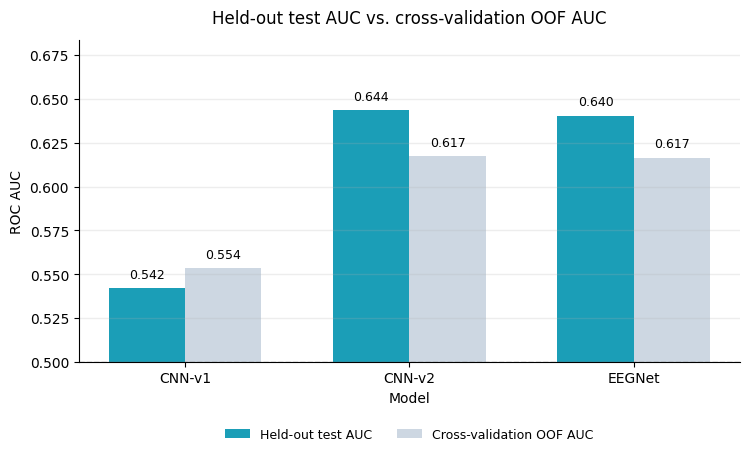

In [44]:
importlib.reload(ra)

fig, ax = ra.plot_test_vs_oof_auc_grouped(
    test_results=test_results,
    baseline_summary=baseline_summary,
    save_path=ra.FIGURES_DIR / "heldout_test_vs_oof_auc_grouped.png",
)